In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style - FIXED VERSION
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('default')  # Fallback to default if seaborn not available

sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("=" * 60)
print("📊 A/B TEST ANALYSIS - MARKETING CAMPAIGN")
print("=" * 60)

# Generate A/B test data
# Scenario: Testing two email campaign versions
# Control: Standard promotional email
# Treatment: Personalized email with dynamic content

n_control = 1000
n_treatment = 1000

# Control group (lower conversion rate: 3.5%)
control_conversions = np.random.binomial(1, 0.035, n_control)
control_revenue = np.where(control_conversions == 1, 
                           np.random.normal(85, 20, n_control), 
                           0)
control_revenue = np.maximum(control_revenue, 0)  # No negative values

# Treatment group (higher conversion rate: 4.8%)
treatment_conversions = np.random.binomial(1, 0.048, n_treatment)
treatment_revenue = np.where(treatment_conversions == 1,
                             np.random.normal(95, 22, n_treatment),
                             0)
treatment_revenue = np.maximum(treatment_revenue, 0)

# Create DataFrames
df_control = pd.DataFrame({
    'group': 'Control',
    'user_id': [f'C_{i:04d}' for i in range(n_control)],
    'converted': control_conversions,
    'revenue': control_revenue,
    'email_opens': np.random.binomial(1, 0.22, n_control),
    'clicks': np.random.binomial(1, 0.08, n_control)
})

df_treatment = pd.DataFrame({
    'group': 'Treatment',
    'user_id': [f'T_{i:04d}' for i in range(n_treatment)],
    'converted': treatment_conversions,
    'revenue': treatment_revenue,
    'email_opens': np.random.binomial(1, 0.28, n_treatment),
    'clicks': np.random.binomial(1, 0.12, n_treatment)
})

# Combine
df = pd.concat([df_control, df_treatment], ignore_index=True)

# Add campaign cost
df['campaign_cost'] = 2.50  # Cost per email sent

print(f"\n✅ Generated {len(df)} test observations")
print(f"   Control group: {n_control} users")
print(f"   Treatment group: {n_treatment} users")
print(f"\nFirst few rows:")
print(df.head(10))

# Save data
df.to_csv('ab_test_data.csv', index=False)
print(f"\n💾 Data saved to 'ab_test_data.csv'")

📊 A/B TEST ANALYSIS - MARKETING CAMPAIGN

✅ Generated 2000 test observations
   Control group: 1000 users
   Treatment group: 1000 users

First few rows:
     group user_id  converted  revenue  email_opens  clicks  campaign_cost
0  Control  C_0000          0      0.0            0       0            2.5
1  Control  C_0001          0      0.0            0       0            2.5
2  Control  C_0002          0      0.0            0       0            2.5
3  Control  C_0003          0      0.0            1       0            2.5
4  Control  C_0004          0      0.0            1       0            2.5
5  Control  C_0005          0      0.0            0       0            2.5
6  Control  C_0006          0      0.0            0       1            2.5
7  Control  C_0007          0      0.0            1       0            2.5
8  Control  C_0008          0      0.0            0       0            2.5
9  Control  C_0009          0      0.0            0       0            2.5

💾 Data saved to 'ab_

In [3]:
print("\n" + "=" * 60)
print("📈 CALCULATING KEY METRICS")
print("=" * 60)

# Group by test variant
results = df.groupby('group').agg({
    'user_id': 'count',
    'converted': ['sum', 'mean'],
    'revenue': ['sum', 'mean'],
    'email_opens': ['sum', 'mean'],
    'clicks': ['sum', 'mean'],
    'campaign_cost': 'sum'
}).round(4)

results.columns = ['Sample_Size', 'Conversions', 'Conversion_Rate', 
                   'Total_Revenue', 'Avg_Revenue_Per_User',
                   'Email_Opens', 'Open_Rate', 
                   'Clicks', 'Click_Rate',
                   'Total_Cost']

print("\n📊 PERFORMANCE SUMMARY BY GROUP:")
print("-" * 60)
print(results)

# Calculate additional metrics
control_data = df[df['group'] == 'Control']
treatment_data = df[df['group'] == 'Treatment']

# Conversion rates
control_conv_rate = control_data['converted'].mean()
treatment_conv_rate = treatment_data['converted'].mean()

# Revenue metrics
control_revenue = control_data['revenue'].sum()
treatment_revenue = treatment_data['revenue'].sum()
control_arpu = control_data['revenue'].mean()
treatment_arpu = treatment_data['revenue'].mean()

# Costs
control_cost = control_data['campaign_cost'].sum()
treatment_cost = treatment_data['campaign_cost'].sum()

# ROI
control_roi = (control_revenue - control_cost) / control_cost * 100
treatment_roi = (treatment_revenue - treatment_cost) / treatment_cost * 100

# Lift calculations
conversion_lift = (treatment_conv_rate - control_conv_rate) / control_conv_rate * 100
revenue_lift = (treatment_arpu - control_arpu) / control_arpu * 100
roi_lift = treatment_roi - control_roi

print("\n" + "=" * 60)
print("💡 KEY INSIGHTS")
print("=" * 60)

print(f"\n🎯 CONVERSION RATE:")
print(f"   Control:   {control_conv_rate:.2%}")
print(f"   Treatment: {treatment_conv_rate:.2%}")
print(f"   Lift:      {conversion_lift:+.2f}%")

print(f"\n💰 REVENUE PER USER:")
print(f"   Control:   ${control_arpu:.2f}")
print(f"   Treatment: ${treatment_arpu:.2f}")
print(f"   Lift:      {revenue_lift:+.2f}%")

print(f"\n📈 RETURN ON INVESTMENT:")
print(f"   Control ROI:   {control_roi:.2f}%")
print(f"   Treatment ROI: {treatment_roi:.2f}%")
print(f"   ROI Increase:  {roi_lift:+.2f} percentage points")

print(f"\n📧 EMAIL ENGAGEMENT:")
control_open_rate = control_data['email_opens'].mean()
treatment_open_rate = treatment_data['email_opens'].mean()
control_click_rate = control_data['clicks'].mean()
treatment_click_rate = treatment_data['clicks'].mean()

print(f"   Open Rate - Control: {control_open_rate:.2%} | Treatment: {treatment_open_rate:.2%}")
print(f"   Click Rate - Control: {control_click_rate:.2%} | Treatment: {treatment_click_rate:.2%}")


📈 CALCULATING KEY METRICS

📊 PERFORMANCE SUMMARY BY GROUP:
------------------------------------------------------------
           Sample_Size  Conversions  Conversion_Rate  Total_Revenue  \
group                                                                 
Control           1000           31            0.031      2728.1653   
Treatment         1000           51            0.051      4891.3410   

           Avg_Revenue_Per_User  Email_Opens  Open_Rate  Clicks  Click_Rate  \
group                                                                         
Control                  2.7282          217      0.217      89       0.089   
Treatment                4.8913          257      0.257     110       0.110   

           Total_Cost  
group                  
Control        2500.0  
Treatment      2500.0  

💡 KEY INSIGHTS

🎯 CONVERSION RATE:
   Control:   3.10%
   Treatment: 5.10%
   Lift:      +64.52%

💰 REVENUE PER USER:
   Control:   $2.73
   Treatment: $4.89
   Lift:      +79.29%


In [4]:
print("\n" + "=" * 60)
print("📊 STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# 1. Two-Proportion Z-Test (Conversion Rate)
print("\n1️⃣ CONVERSION RATE TEST (Two-Proportion Z-Test)")
print("-" * 60)

# Calculate pooled proportion
n1 = len(control_data)
n2 = len(treatment_data)
p1 = control_conv_rate
p2 = treatment_conv_rate
p_pooled = (control_data['converted'].sum() + treatment_data['converted'].sum()) / (n1 + n2)

# Calculate z-statistic
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
z_score = (p2 - p1) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"   Control conversion rate:    {p1:.4f} ({p1:.2%})")
print(f"   Treatment conversion rate:  {p2:.4f} ({p2:.2%})")
print(f"   Difference:                 {(p2-p1):.4f} ({conversion_lift:+.2f}% lift)")
print(f"   Z-score:                    {z_score:.4f}")
print(f"   P-value:                    {p_value:.6f}")

if p_value < 0.05:
    print(f"   ✅ Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"   → Treatment performs significantly better than Control")
else:
    print(f"   ❌ Result: NOT statistically significant (p >= 0.05)")
    print(f"   → Cannot conclude Treatment is better than Control")

# 2. Two-Sample T-Test (Revenue Per User)
print("\n2️⃣ REVENUE PER USER TEST (Two-Sample T-Test)")
print("-" * 60)

t_stat, p_value_ttest = stats.ttest_ind(
    treatment_data['revenue'], 
    control_data['revenue'],
    equal_var=False  # Welch's t-test
)

print(f"   Control avg revenue:   ${control_arpu:.2f}")
print(f"   Treatment avg revenue: ${treatment_arpu:.2f}")
print(f"   Difference:            ${treatment_arpu - control_arpu:.2f} ({revenue_lift:+.2f}% lift)")
print(f"   T-statistic:           {t_stat:.4f}")
print(f"   P-value:               {p_value_ttest:.6f}")

if p_value_ttest < 0.05:
    print(f"   ✅ Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"   → Treatment generates significantly more revenue per user")
else:
    print(f"   ❌ Result: NOT statistically significant (p >= 0.05)")

# 3. Effect Size (Cohen's d for practical significance)
print("\n3️⃣ EFFECT SIZE ANALYSIS (Cohen's d)")
print("-" * 60)

pooled_std = np.sqrt(((n1-1)*control_data['revenue'].std()**2 + 
                      (n2-1)*treatment_data['revenue'].std()**2) / (n1+n2-2))
cohens_d = (treatment_arpu - control_arpu) / pooled_std

print(f"   Cohen's d: {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    effect_interpretation = "Small effect size"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "Medium effect size"
else:
    effect_interpretation = "Large effect size"

print(f"   Interpretation: {effect_interpretation}")

# 4. Confidence Intervals
print("\n4️⃣ CONFIDENCE INTERVALS (95%)")
print("-" * 60)

# CI for conversion rate difference
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_lower = (p2 - p1) - 1.96 * se_diff
ci_upper = (p2 - p1) + 1.96 * se_diff

print(f"   Conversion rate difference: {(p2-p1):.4f}")
print(f"   95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"   → We're 95% confident the true difference is between {ci_lower:.2%} and {ci_upper:.2%}")

# CI for revenue difference
se_revenue = np.sqrt(control_data['revenue'].var()/n1 + treatment_data['revenue'].var()/n2)
revenue_diff = treatment_arpu - control_arpu
ci_rev_lower = revenue_diff - 1.96 * se_revenue
ci_rev_upper = revenue_diff + 1.96 * se_revenue

print(f"\n   Revenue per user difference: ${revenue_diff:.2f}")
print(f"   95% CI: [${ci_rev_lower:.2f}, ${ci_rev_upper:.2f}]")


📊 STATISTICAL SIGNIFICANCE TESTS

1️⃣ CONVERSION RATE TEST (Two-Proportion Z-Test)
------------------------------------------------------------
   Control conversion rate:    0.0310 (3.10%)
   Treatment conversion rate:  0.0510 (5.10%)
   Difference:                 0.0200 (+64.52% lift)
   Z-score:                    2.2553
   P-value:                    0.024111
   ✅ Result: STATISTICALLY SIGNIFICANT (p < 0.05)
   → Treatment performs significantly better than Control

2️⃣ REVENUE PER USER TEST (Two-Sample T-Test)
------------------------------------------------------------
   Control avg revenue:   $2.73
   Treatment avg revenue: $4.89
   Difference:            $2.16 (+79.29% lift)
   T-statistic:           2.5583
   P-value:               0.010601
   ✅ Result: STATISTICALLY SIGNIFICANT (p < 0.05)
   → Treatment generates significantly more revenue per user

3️⃣ EFFECT SIZE ANALYSIS (Cohen's d)
------------------------------------------------------------
   Cohen's d: 0.1144
   Int


📊 CREATING VISUALIZATIONS
✅ Dashboard saved to 'ab_test_dashboard.png'


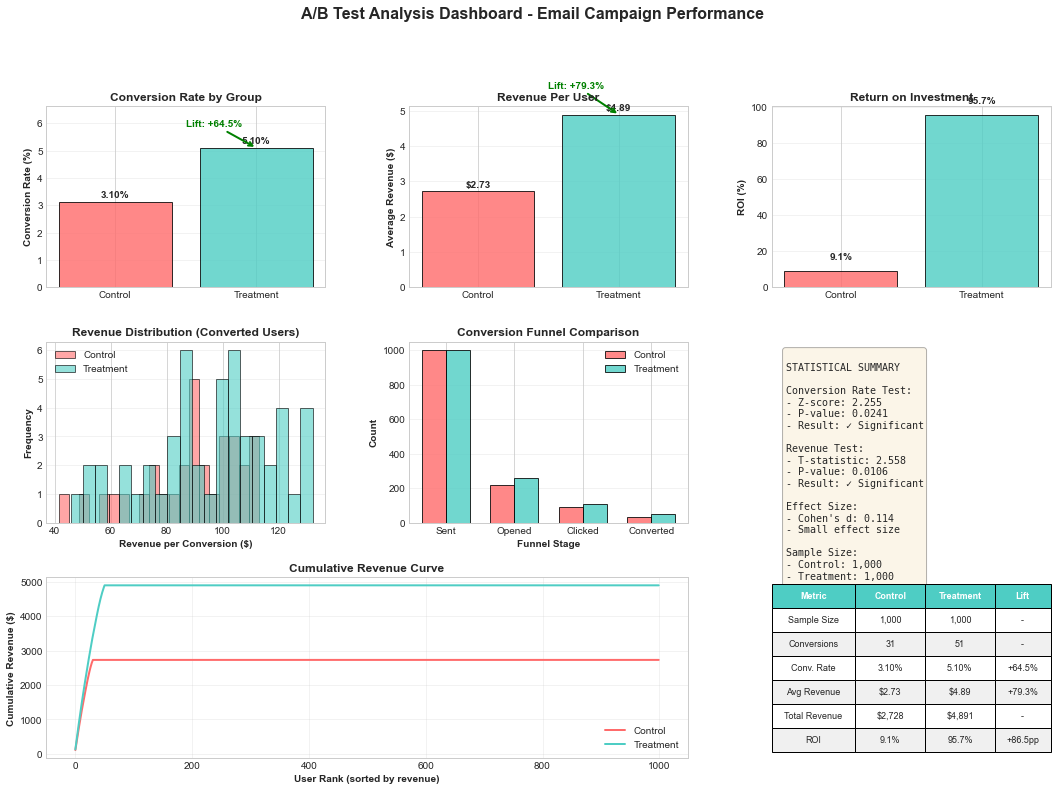

In [5]:
print("\n" + "=" * 60)
print("📊 CREATING VISUALIZATIONS")
print("=" * 60)

# Create comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Color scheme
color_control = '#FF6B6B'
color_treatment = '#4ECDC4'

# 1. Conversion Rate Comparison
ax1 = fig.add_subplot(gs[0, 0])
groups = ['Control', 'Treatment']
conv_rates = [control_conv_rate * 100, treatment_conv_rate * 100]
bars = ax1.bar(groups, conv_rates, color=[color_control, color_treatment], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Conversion Rate (%)', fontweight='bold')
ax1.set_title('Conversion Rate by Group', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(conv_rates) * 1.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, conv_rates)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add lift annotation
ax1.annotate(f'Lift: {conversion_lift:+.1f}%', 
             xy=(1, conv_rates[1]), xytext=(0.5, max(conv_rates) * 1.15),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, fontweight='bold', color='green')

ax1.grid(axis='y', alpha=0.3)

# 2. Revenue Per User Comparison
ax2 = fig.add_subplot(gs[0, 1])
revenue_values = [control_arpu, treatment_arpu]
bars2 = ax2.bar(groups, revenue_values, color=[color_control, color_treatment], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Average Revenue ($)', fontweight='bold')
ax2.set_title('Revenue Per User', fontsize=12, fontweight='bold')

for bar, val in zip(bars2, revenue_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.annotate(f'Lift: {revenue_lift:+.1f}%',
             xy=(1, revenue_values[1]), xytext=(0.5, max(revenue_values) * 1.15),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, fontweight='bold', color='green')

ax2.grid(axis='y', alpha=0.3)

# 3. ROI Comparison
ax3 = fig.add_subplot(gs[0, 2])
roi_values = [control_roi, treatment_roi]
bars3 = ax3.bar(groups, roi_values, color=[color_control, color_treatment], alpha=0.8, edgecolor='black')
ax3.set_ylabel('ROI (%)', fontweight='bold')
ax3.set_title('Return on Investment', fontsize=12, fontweight='bold')
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

for bar, val in zip(bars3, roi_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val > 0 else -10),
             f'{val:.1f}%', ha='center', va='bottom' if val > 0 else 'top', 
             fontweight='bold', fontsize=10)

ax3.grid(axis='y', alpha=0.3)

# 4. Revenue Distribution (only converted users)
ax4 = fig.add_subplot(gs[1, 0])
control_rev_converted = control_data[control_data['converted'] == 1]['revenue']
treatment_rev_converted = treatment_data[treatment_data['converted'] == 1]['revenue']

if len(control_rev_converted) > 0 and len(treatment_rev_converted) > 0:
    ax4.hist(control_rev_converted, bins=20, alpha=0.6, label='Control', color=color_control, edgecolor='black')
    ax4.hist(treatment_rev_converted, bins=20, alpha=0.6, label='Treatment', color=color_treatment, edgecolor='black')
    ax4.set_xlabel('Revenue per Conversion ($)', fontweight='bold')
    ax4.set_ylabel('Frequency', fontweight='bold')
    ax4.set_title('Revenue Distribution (Converted Users)', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Insufficient conversion data', ha='center', va='center', transform=ax4.transAxes)

# 5. Conversion Funnel
ax5 = fig.add_subplot(gs[1, 1])
funnel_data = pd.DataFrame({
    'Stage': ['Sent', 'Opened', 'Clicked', 'Converted'],
    'Control': [
        n_control,
        control_data['email_opens'].sum(),
        control_data['clicks'].sum(),
        control_data['converted'].sum()
    ],
    'Treatment': [
        n_treatment,
        treatment_data['email_opens'].sum(),
        treatment_data['clicks'].sum(),
        treatment_data['converted'].sum()
    ]
})

x = np.arange(len(funnel_data))
width = 0.35

bars_c = ax5.bar(x - width/2, funnel_data['Control'], width, label='Control', 
                 color=color_control, alpha=0.8, edgecolor='black')
bars_t = ax5.bar(x + width/2, funnel_data['Treatment'], width, label='Treatment',
                 color=color_treatment, alpha=0.8, edgecolor='black')

ax5.set_xlabel('Funnel Stage', fontweight='bold')
ax5.set_ylabel('Count', fontweight='bold')
ax5.set_title('Conversion Funnel Comparison', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(funnel_data['Stage'])
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Statistical Summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

summary_text = f"""
STATISTICAL SUMMARY

Conversion Rate Test:
- Z-score: {z_score:.3f}
- P-value: {p_value:.4f}
- Result: {"✓ Significant" if p_value < 0.05 else "✗ Not Significant"}

Revenue Test:
- T-statistic: {t_stat:.3f}
- P-value: {p_value_ttest:.4f}
- Result: {"✓ Significant" if p_value_ttest < 0.05 else "✗ Not Significant"}

Effect Size:
- Cohen's d: {cohens_d:.3f}
- {effect_interpretation}

Sample Size:
- Control: {n_control:,}
- Treatment: {n_treatment:,}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 7. Cumulative Revenue
ax7 = fig.add_subplot(gs[2, :2])
control_sorted = control_data.sort_values('revenue', ascending=False).reset_index(drop=True)
treatment_sorted = treatment_data.sort_values('revenue', ascending=False).reset_index(drop=True)

control_cumsum = control_sorted['revenue'].cumsum()
treatment_cumsum = treatment_sorted['revenue'].cumsum()

ax7.plot(control_cumsum.index, control_cumsum.values, label='Control', 
         color=color_control, linewidth=2)
ax7.plot(treatment_cumsum.index, treatment_cumsum.values, label='Treatment',
         color=color_treatment, linewidth=2)
ax7.set_xlabel('User Rank (sorted by revenue)', fontweight='bold')
ax7.set_ylabel('Cumulative Revenue ($)', fontweight='bold')
ax7.set_title('Cumulative Revenue Curve', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(alpha=0.3)

# 8. Key Metrics Table
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

metrics_data = [
    ['Metric', 'Control', 'Treatment', 'Lift'],
    ['Sample Size', f'{n_control:,}', f'{n_treatment:,}', '-'],
    ['Conversions', f'{int(control_data["converted"].sum())}', f'{int(treatment_data["converted"].sum())}', '-'],
    ['Conv. Rate', f'{control_conv_rate:.2%}', f'{treatment_conv_rate:.2%}', f'{conversion_lift:+.1f}%'],
    ['Avg Revenue', f'${control_arpu:.2f}', f'${treatment_arpu:.2f}', f'{revenue_lift:+.1f}%'],
    ['Total Revenue', f'${control_revenue:,.0f}', f'${treatment_revenue:,.0f}', '-'],
    ['ROI', f'{control_roi:.1f}%', f'{treatment_roi:.1f}%', f'{roi_lift:+.1f}pp'],
]

table = ax8.table(cellText=metrics_data, cellLoc='center', loc='center',
                  colWidths=[0.3, 0.25, 0.25, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(metrics_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')

plt.suptitle('A/B Test Analysis Dashboard - Email Campaign Performance', 
             fontsize=16, fontweight='bold', y=0.995)

# Save
plt.savefig('ab_test_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard saved to 'ab_test_dashboard.png'")

plt.show()

In [7]:
# 1. 創建project folder
mkdir ab-test-analysis
cd ab-test-analysis

# 2. 初始化git
git init

# 3. 移動你的files到這個folder
# (如果你的files在別的地方，用這個command移過來)
# 假設你的files在當前目錄的上一層
cp ../ab_test_data.csv .
cp ../ab_test_dashboard.png .
# 如果你有Jupyter notebook，也copy過來
# cp

SyntaxError: invalid syntax (<ipython-input-7-63f0d14e9372>, line 2)